In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import importlib
import dls as dls

In [29]:
data_path = '../data/gencarr_transpose.h5'
patch_size = 5
num_modes = 1

In [30]:
with h5py.File(data_path, 'r') as f:
    print(f.keys())
    mean = f['mean'][:]
    data = f['UV'][:2]
    x_grid = f['x_grid'][:]
    y_grid = f['y_grid'][:]
    z_grid = f['z_grid'][:]
    print(f['UV'].shape)
    print( f['mean'].shape)
    input_dict = {
        'UV': f['UV'][:12],
        'mean': f['mean'][:],
        'x_grid': f['x_grid'][:],
        'y_grid': f['y_grid'][:],
        'z_grid': f['z_grid'][:]
    }

<KeysViewHDF5 ['RMS_gt_0aoa_dls_p19m10_0aoa', 'RMS_gt_0aoa_dls_p19m10_0aoaeval_data', 'RMS_gt_0aoa_dls_p19m10_0aoatrain_data', 'RMS_gt_0aoa_dls_p21m25_0aoaeval_data', 'RMS_gt_0aoa_dls_p21m25_0aoatrain_data', 'TKE_gt_0aoa_dls_p19m10_0aoa', 'TKE_gt_0aoa_dls_p19m10_0aoaeval_data', 'TKE_gt_0aoa_dls_p19m10_0aoatrain_data', 'TKE_gt_0aoa_dls_p21m25_0aoaeval_data', 'TKE_gt_0aoa_dls_p21m25_0aoatrain_data', 'UV', 'mean', 'weights', 'x_grid', 'y_grid', 'z_grid']>
(600, 542, 85, 43, 3)
(542, 85, 43, 3)


/tmp/ipykernel_207304/3784784979.py:12: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


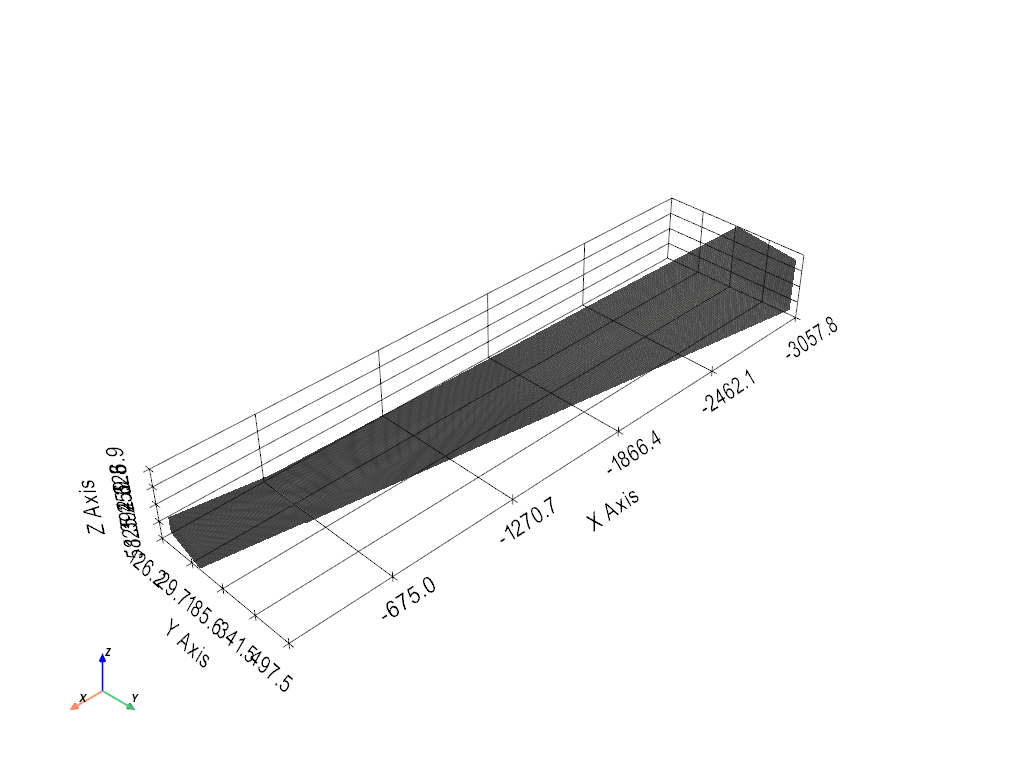

In [31]:
# Visualize the given mesh without data
# Create a PyVista mesh
mesh = pv.StructuredGrid(-x_grid, y_grid, z_grid)
# print min z value
# print("Min z value:", np.min(z_grid))
# Visualize the mesh without data
plotter = pv.Plotter()
plotter.add_mesh(mesh, show_edges=True, color='lightgray', opacity=0.5)
#add axes and ticks
plotter.show_axes()
plotter.show_grid()
plotter.show()

In [ ]:
importlib.reload(dls)
latent_config, dof_u, dof_v, dof_w = dls.gfem_compress_flexible(data_source=input_dict,
                           field_name='UV',
                           patch_size=patch_size,
                           num_modes=num_modes)
# latent_config = dls.gfem_3d_long(data_path, field_name, latent_path, patch_size, num_modes, batch_size)

In [ ]:
from lib.weights import generate_weights_grid_3d as generate_weights_grid
importlib.reload(generate_weights_grid)
weights = generate_weights_grid.generate_weights_grid(x_grid, y_grid, z_grid)

In [10]:
importlib.reload(dls)
importlib.reload(dls)
Q_rec = dls.gfem_3d_recon_flexible(
    rec_target=None,
    config=latent_config,
    dof_u=dof_u,
    dof_v=dof_v,
    dof_w=dof_w,
    batch_size=2,
)

nx_t, ny_t, nz_t = latent_config.nx_t, latent_config.ny_t, latent_config.nz_t

print("Q_rec shape:", Q_rec.shape)
print("weights shape:", weights.shape)
Q_rec_weighted = Q_rec * weights[np.newaxis, :nx_t, :ny_t, :nz_t, np.newaxis]

Processing batch 1/1, batch size: 2, processed in 0.37s
Total reconstruction time not with saving to disk: 0.38s

Q_rec shape: (2, 541, 82, 37, 3)
weights shape: (542, 85, 43)


(2, 541, 82, 37, 3)


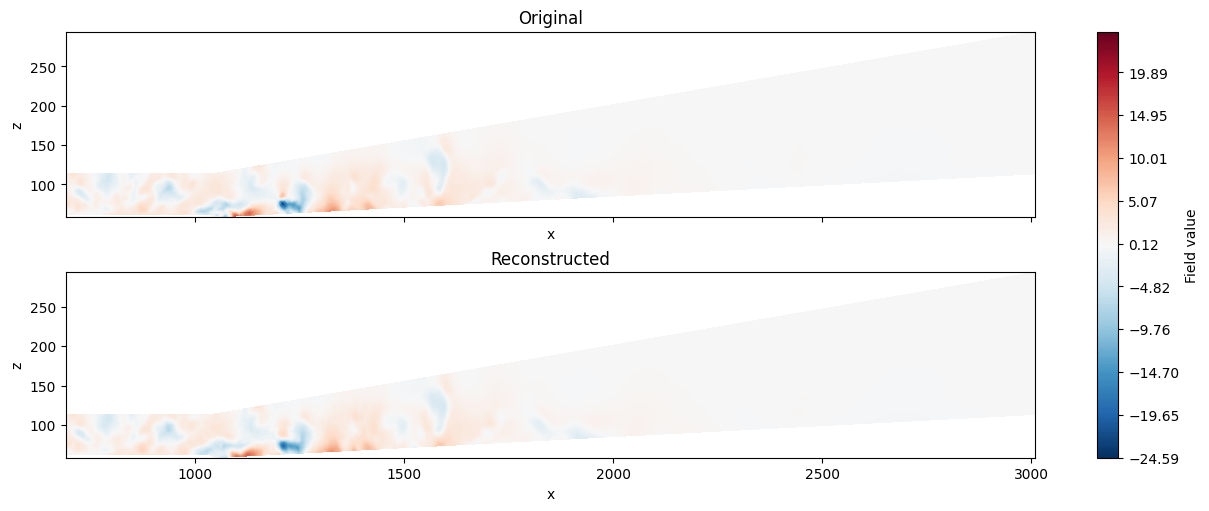

In [19]:
print(Q_rec.shape)

nx_t, ny_t, nz_t = latent_config.nx_t, latent_config.ny_t, latent_config.nz_t
x_trunc = x_grid[:nx_t, :ny_t, :nz_t]
y_trunc = y_grid[:nx_t, :ny_t, :nz_t]
z_trunc = z_grid[:nx_t, :ny_t, :nz_t]

snap_idx = 1
comp_idx = 0   # 0:u, 1:v, 2:w
y_idx = min(40, ny_t - 1)

q_true = data[snap_idx, :nx_t, :ny_t, :nz_t, comp_idx] - mean[:nx_t, :ny_t, :nz_t, comp_idx]
q_rec = Q_rec[snap_idx, :, :, :, comp_idx]

true_slice = q_true[:, y_idx, :]
rec_slice = q_rec[:, y_idx, :]

absmax = np.max(np.abs((true_slice)))
vmin, vmax = np.min(true_slice), np.max(true_slice)
levels = np.linspace(-absmax, absmax, 200)

fig, ax = plt.subplots(2,1, figsize=(12,5), sharex=True, sharey=True, constrained_layout=True)

c0 = ax[0].contourf(
    x_trunc[:, y_idx, :], z_trunc[:, y_idx, :], true_slice,
    levels=levels, cmap='RdBu_r'
)
ax[0].set_title("Original")
ax[0].set_xlabel("x")
ax[0].set_ylabel("z")
# ax[0].set_aspect('equal')

c1 = ax[1].contourf(
    x_trunc[:, y_idx, :], z_trunc[:, y_idx, :], rec_slice,
    levels=levels, cmap='RdBu_r'
)
ax[1].set_title("Reconstructed")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")
# ax[1].set_aspect('equal')

fig.colorbar(c1, ax=ax, label="Field value")
plt.show()

In [12]:
import os

os.makedirs("figures", exist_ok=True)

snap_idx = 0
iso_value = 0.1

def compute_q_criterion(vel_grid, x, y, z):
    grid = pv.StructuredGrid(x, y, z)
    grid["velocity"] = vel_grid.reshape(-1, 3, order="F")
    grad = grid.compute_derivative(scalars="velocity", gradient=True)
    g = grad["gradient"].reshape(-1, 3, 3)
    S = 0.5 * (g + g.transpose(0, 2, 1))
    Omega = 0.5 * (g - g.transpose(0, 2, 1))
    q_val = 0.5 * (np.sum(Omega**2, axis=(1, 2)) - np.sum(S**2, axis=(1, 2)))
    grid["Q-criterion"] = q_val
    return grid

q_true = data[snap_idx, :nx_t, :ny_t, :nz_t, :] - mean[:nx_t, :ny_t, :nz_t, :]
q_rec = Q_rec[snap_idx]

x_max = 400

grid_true = compute_q_criterion(q_true[:x_max], -x_trunc[:x_max], y_trunc[:x_max], z_trunc[:x_max])
grid_rec = compute_q_criterion(q_rec[:x_max], -x_trunc[:x_max], y_trunc[:x_max], z_trunc[:x_max])

contour_true = grid_true.contour(isosurfaces=[iso_value], scalars="Q-criterion")
contour_rec = grid_rec.contour(isosurfaces=[iso_value], scalars="Q-criterion")

pl = pv.Plotter(shape=(1, 2), window_size=(1600, 800), off_screen=True)

pl.subplot(0, 0)
pl.add_mesh(contour_true, color="lightblue", opacity=0.7)
pl.add_mesh(grid_true.outline(), color="black")
pl.add_text("Original", font_size=12)

pl.subplot(0, 1)
pl.add_mesh(contour_rec, color="lightblue", opacity=0.7)
pl.add_mesh(grid_rec.outline(), color="black")
pl.add_text("Reconstructed", font_size=12)

pl.link_views()
pl.view_isometric()

out_path = "figures/q_criterion_comparison.png"
pl.screenshot(out_path)
pl.close()

print(f"Saved to {out_path}")

2026-05-03 21:18:18.664 ( 227.854s) [    7845BF2C0080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Saved to figures/q_criterion_comparison.png


In [13]:
# computer error between reconstructed and original snapshots
Q_true = data[:,:nx_t, :ny_t, :nz_t] - mean[:nx_t, :ny_t, :nz_t]
L2_error = np.linalg.norm(Q_rec - Q_true) / np.linalg.norm(Q_true)
print(f"% L2 error: {100*L2_error:.4f}")

% L2 error: 15.9278
